In [1]:
import cv2
import numpy as np
from PIL import Image
import os

def auto_crop_stickers(image_path, output_dir, min_area=5000):
    """
    自动检测并裁剪每个贴纸
    min_area: 最小面积过滤（过滤掉噪点）
    """
    # 读取图片
    img = cv2.imread(image_path)
    original = img.copy()
    height, width = img.shape[:2]

    # 1. 转为灰度图
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. 高斯模糊降噪
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. 二值化（假设贴纸在白色背景上）
    _, thresh = cv2.threshold(blurred, 240, 255, cv2.THRESH_BINARY_INV)

    # 4. 形态学操作（去除小噪点，连接断开的区域）
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)

    # 5. 查找轮廓
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    os.makedirs(output_dir, exist_ok=True)

    # 6. 处理每个轮廓
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)

        # 过滤太小的区域
        if area < min_area:
            continue

        # 获取边界框
        x, y, w, h = cv2.boundingRect(contour)

        # 添加一点边距
        padding = 10
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(width - x, w + 2*padding)
        h = min(height - y, h + 2*padding)

        # 裁剪
        cropped = original[y:y+h, x:x+w]

        # 保存
        cv2.imwrite(f"{output_dir}/sticker_{i:03d}.png", cropped)

        # 可选：在原图上画框（用于调试）
        cv2.rectangle(original, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # 保存标注后的图片
    cv2.imwrite(f"{output_dir}/detected_boxes.jpg", original)
    print(f"找到 {i+1} 个贴纸")

# 使用
# auto_crop_stickers("VCG211486349220.jpg", "cropped20/")
# auto_crop_stickers("VCG211486349416.jpg", "cropped16/")
# auto_crop_stickers("VCG211486349504.jpg", "cropped04/")
auto_crop_stickers("VCG211486349446.jpg", "cropped46/")

找到 10 个贴纸


In [2]:
# !zip -r cropped04.zip cropped04
# !zip -r cropped16.zip cropped16
# !zip -r cropped20.zip cropped20
# !zip -r cropped89.zip cropped89
!zip -r cropped46.zip cropped46

  adding: cropped46/ (stored 0%)
  adding: cropped46/sticker_007.png (deflated 1%)
  adding: cropped46/sticker_003.png (deflated 0%)
  adding: cropped46/sticker_004.png (deflated 0%)
  adding: cropped46/sticker_009.png (deflated 1%)
  adding: cropped46/detected_boxes.jpg (deflated 9%)
  adding: cropped46/sticker_008.png (deflated 1%)
  adding: cropped46/sticker_005.png (deflated 0%)
  adding: cropped46/sticker_000.png (deflated 12%)
  adding: cropped46/sticker_002.png (deflated 1%)
  adding: cropped46/sticker_001.png (deflated 0%)
  adding: cropped46/sticker_006.png (deflated 1%)


In [5]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install diffusers accelerate transformers peft pillow tqdm
!pip install xformers  # 优化显存

print("✅")

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 25.4 MB/s eta 0:00:00
✅


In [6]:
# @title 2. Connect Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/sticker_project"
data_path = os.path.join(project_path, "data/my_sticker_style")
lora_path = os.path.join(project_path, "lora_weights")

os.makedirs(data_path, exist_ok=True)
os.makedirs(lora_path, exist_ok=True)

print(f"✅ Google Drive")
print(f"📁 Data path: {data_path}")
print(f"📁 LoRA path: {lora_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive
📁 Data path: /content/drive/MyDrive/sticker_project/data/my_sticker_style
📁 LoRA path: /content/drive/MyDrive/sticker_project/lora_weights


In [7]:
# @title 3. Start training(about 20-25 min)
!python /content/drive/MyDrive/sticker_project/train_lora_colab.py --train

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.

=== Step 1: Data Augmentation ===
Found 27 original images
Generating 4 augmented versions per image....
Data Augmentation: 100% 27/27 [00:20<00:00,  1.33it/s]
✅ Augmentation complete! Total 135 images

=== Step 2: Load Pretrained model ===
model_index.json: 100% 541/541 [00:00<00:00, 3.15MB/s]
Fetching 13 files:   8% 1/13 [00:00<00:02,  5.89it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Fetching 13 files: 100% 13/13 [00:53<00:00,  4.12s/it]
Download complete: : 4.27GB [00:53, 80.6MB/s]              
Download complete: : 4.27GB [00:53, 79.4MB/s]

Loading pipeline components...:  17% 1/6 [00:00<00:0

Latest validation samples:

--- step_1200_cat.png ---


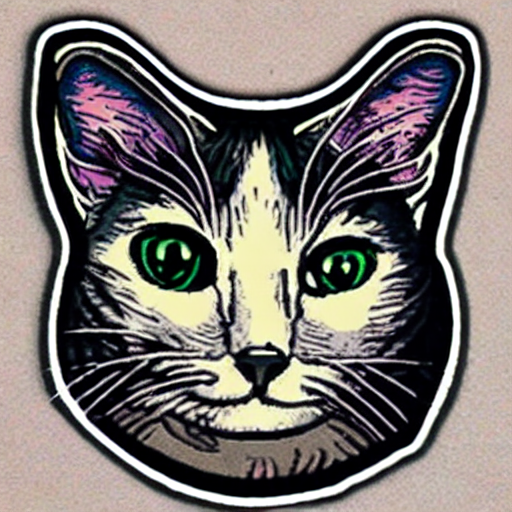


--- step_1200_dog.png ---


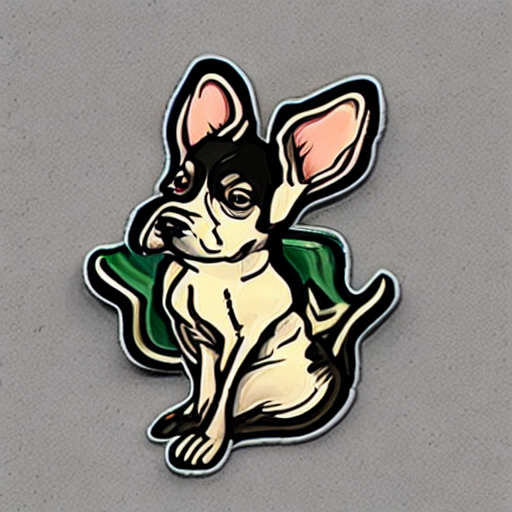


--- step_1200_rabbit.png ---


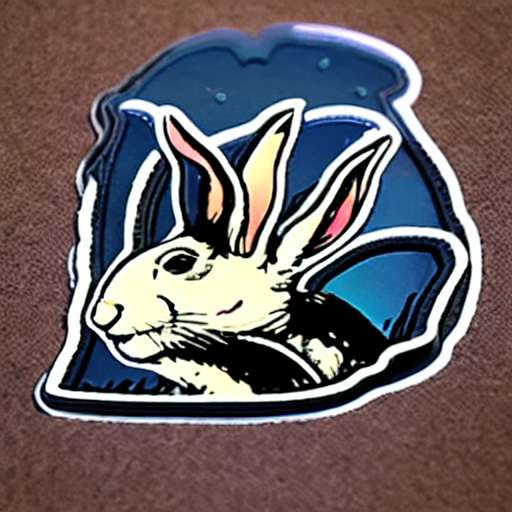

In [8]:
# @title 4. View verification samples
from IPython.display import Image, display
import os

validation_dir = "/content/validation_samples"
if os.path.exists(validation_dir):
    print("Latest validation samples:")
    files = sorted(os.listdir(validation_dir))[3:6]  # last 3 validation
    for f in files:
        print(f"\n--- {f} ---")
        display(Image(os.path.join(validation_dir, f)))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Load LoRA: /content/drive/MyDrive/sticker_project/lora_weights/lora_final
Loading pipeline components...:  17% 1/6 [00:00<00:01,  2.82it/s]
Loading weights:   0% 0/196 [00:00<?, ?it/s]
Loading weights:   1% 1/196 [00:00<00:00, 9058.97it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   1% 1/196 [00:00<00:00, 4116.10it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   1% 2/196 [00:00<00:00, 3763.40it/s, Materializing param=text_model.embeddings.token_embedding.weight]   
Loading weights:   1% 2/196 [00:00<00:00, 2522.89it/s, Materializing param=text_model.embeddings.token_embedding.weight]
Loading weights:   2% 3/

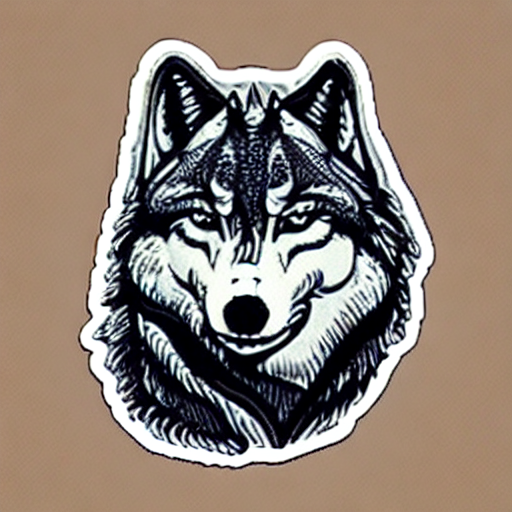


--- fish_sticker_1.png ---


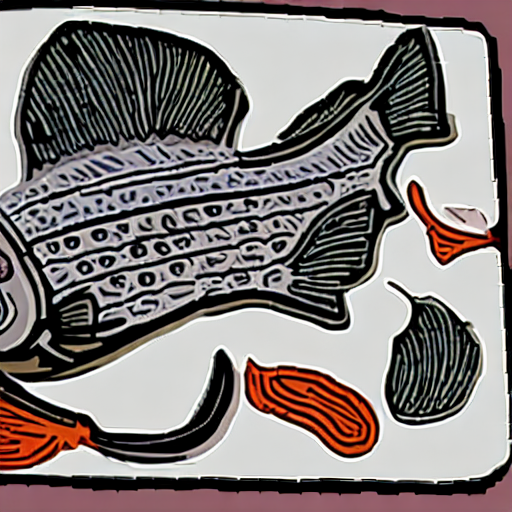


--- cat_sticker_0.png ---


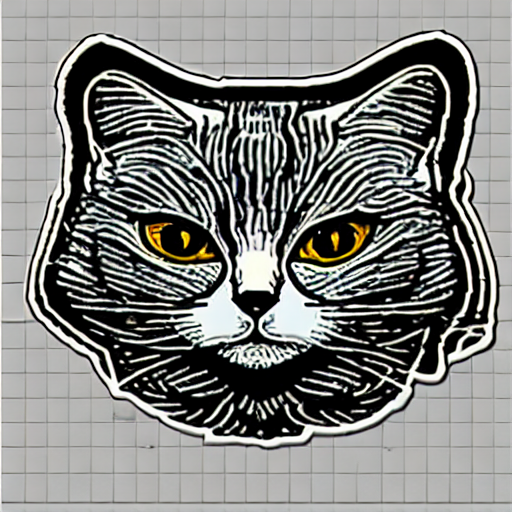


--- fish_sticker_0.png ---


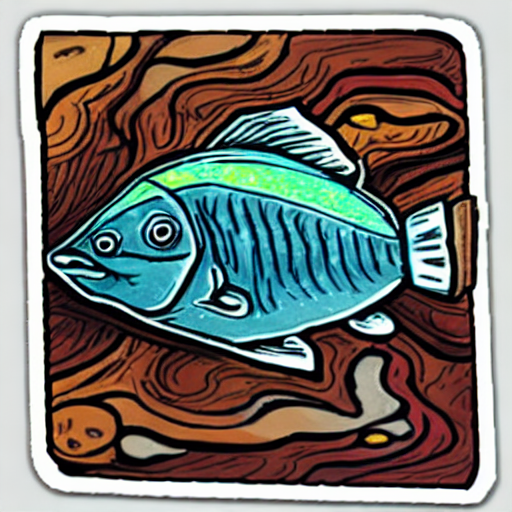


--- bear_sticker_1.png ---


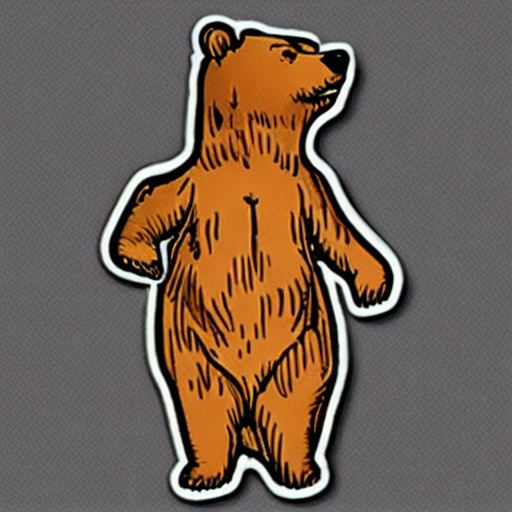


--- fox_sticker_1.png ---


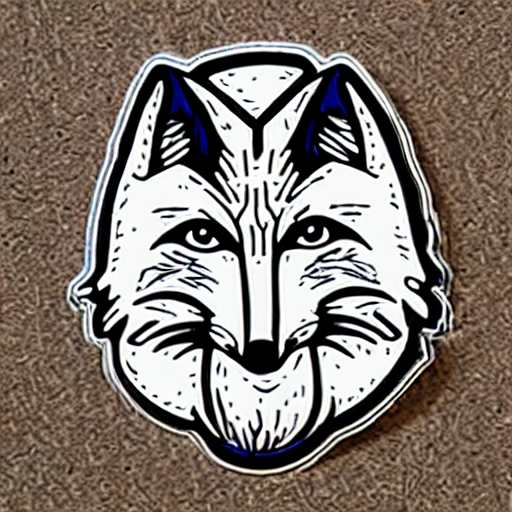

In [9]:
# @title 5. Test generated stickers
!python /content/drive/MyDrive/sticker_project/train_lora_colab.py --test

from IPython.display import Image, display
import os

test_dir = "/content/test_output"
if os.path.exists(test_dir):
    print("Generated stickers:")
    for f in os.listdir(test_dir)[:6]:
        if f.endswith('.png'):
            print(f"\n--- {f} ---")
            display(Image(os.path.join(test_dir, f)))

In [15]:
# @title 6. Download the pre-trained LoRA and the generated stickers
from google.colab import files
import os

!cd /content/drive/MyDrive/sticker_project && zip -r lora_weights.zip lora_weights
!cp /content/drive/MyDrive/sticker_project/lora_weights.zip /content/

print("下载LoRA权重：")
files.download('/content/lora_weights.zip')

print("\n下载测试图片：")
if os.path.exists('/content/test_output.zip'):
    files.download('/content/test_output.zip')

  adding: lora_weights/ (stored 0%)
  adding: lora_weights/lora_step_200/ (stored 0%)
  adding: lora_weights/lora_step_200/README.md (deflated 65%)
  adding: lora_weights/lora_step_200/adapter_model.safetensors (deflated 7%)
  adding: lora_weights/lora_step_200/adapter_config.json (deflated 58%)
  adding: lora_weights/lora_step_400/ (stored 0%)
  adding: lora_weights/lora_step_400/README.md (deflated 65%)
  adding: lora_weights/lora_step_400/adapter_model.safetensors (deflated 7%)
  adding: lora_weights/lora_step_400/adapter_config.json (deflated 58%)
  adding: lora_weights/lora_step_600/ (stored 0%)
  adding: lora_weights/lora_step_600/README.md (deflated 65%)
  adding: lora_weights/lora_step_600/adapter_model.safetensors (deflated 7%)
  adding: lora_weights/lora_step_600/adapter_config.json (deflated 58%)
  adding: lora_weights/lora_step_800/ (stored 0%)
  adding: lora_weights/lora_step_800/README.md (deflated 65%)
  adding: lora_weights/lora_step_800/adapter_model.safetensors (defla

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>